## makes aral sea balance

In [1]:
# setup imports
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]  # pas aan als notebook dieper/dichter zit
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

import fiona
import shapely.geometry
from pyproj import Geod
from ewatercycle.observation.grdc import get_grdc_data


from src.paths import *
from src.forcing import generate_lumped_ERA5_forcing,load_lumped_forcing_data
from src.models import simulate_HBV,save_HBV_results
from src.utils import mmday_to_m3s
from src.constants import TYUMEN_ARYK_HBV_PARAMS_CMAES
import src.aral as aral

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


In [2]:
### generate forcing
experiment_start_date = "1940-01-01T00:00:00Z"
experiment_end_date = "2020-12-31T00:00:00Z"

shapefile_kerki = "Kerki_GRDC"
shapefile_TA = "Tyumen_Aryk_GRDC"
shapefile_Aral = "AralSea"

# ERA5_forcing_kerki = generate_lumped_ERA5_forcing(shapefile_kerki, experiment_start_date, experiment_end_date)
# ERA5_forcing_TA = generate_lumped_ERA5_forcing(shapefile_TA, experiment_start_date, experiment_end_date)
# ERA5_forcing_Aral = generate_lumped_ERA5_forcing(shapefile_Aral, experiment_start_date, experiment_end_date)

In [3]:
### imports

#Parameters HBV model after calibration with CMA-ES:

parameter_set = [
    8.507048,   # Imax
    0.566942,   # Ce
    448.172323, # Sumax
    0.714943,   # Beta
    0.045901,   # Pmax
    2.377915,   # Tlag
    0.011572,   # Kf
    0.004388,   # Ks
    0.422621    # FM
]

# Initial conditions placeholder
initial_conditions = np.array([
    0,      # Si
    100,    # Su
    0,      # Sf
    5,      # Ss
    0       # Sp
])

#kerki simulation
#simulatie_kerki = simulate_HBV(ERA5_forcing_kerki, parameter_set=parameter_set, initial_conditions=initial_conditions)
#kerki_hbv_m3 = mmday_to_m3s(simulatie_kerki, shapefile_kerki)
#saved_files  = save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
#print(saved_files)
#simulatie_TA = simulate_HBV(ERA5_forcing_TA, parameter_set  )
#save_HBV_results(simulatie_kerki,shape_name=shapefile_kerki, forcing_type="ERA5" )
#simulatie_Aral = simulate_HBV(ERA5_forcing_Aral, parameter_set  )   



In [4]:
# forcing_TA = load_lumped_forcing_data(shape_name=shapefile_TA, forcing_type="ERA5", year_span="1940-2020")
# simulatie_TA = simulate_HBV(forcing_TA, parameter_set=TYUMEN_ARYK_HBV_PARAMS_CMAES, initial_conditions=initial_conditions)
# save_HBV_results(simulatie_TA,shape_name=shapefile_TA, forcing_type="ERA5" )

In [5]:
import pandas as pd

path_to_kerki = OUTPUT_HBV / "Kerki_GRDC" / "ERA5" / "Kerki_GRDC_ERA5_1940-2020.pkl"
path_to_TA = OUTPUT_HBV / "Tyumen_Aryk_GRDC" / "ERA5" / "Tyumen_Aryk_GRDC_ERA5_1940-2020.pkl"
# Read the pickle
df_kerki = pd.read_pickle(path_to_kerki)
df_TA = pd.read_pickle(path_to_TA)


#test
df_kerki = df_kerki
df_TA = df_TA

In [6]:
River_Amu_Darya = aral.River(df_kerki, q_col="m3_s", name= "Amu Darya") #scaling = 0.8)
River_Syr_Darya = aral.River(df_TA, q_col="m3_s", name= "Syr Darya", scaling = 0.25)

In [7]:
grdc_start_date = '1900-01-02T00:00Z'
grdc_end_date = '2000-12-31T00:00Z'

kerki = 2617110
tyumen_aryk = 2316200

grdc_kerki = get_grdc_data(kerki,
                   grdc_start_date,
                   grdc_end_date,
                   data_home=GRDC/'Daily')
grdc_tyumen_aryk = get_grdc_data(tyumen_aryk,
                   grdc_start_date,
                   grdc_end_date,
                   data_home=GRDC/'Daily')

River_Amu_Darya_grdc = aral.River(grdc_kerki, q_col="streamflow", name= "Amu Darya GRDC")
River_Syr_Darya_grdc = aral.River(grdc_tyumen_aryk, q_col="streamflow", name= "Syr Darya GRDC")

In [8]:
aral_meteo = xr.open_dataset('/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/forcing/output/ERA5/AralSea/1940-2020/work/diagnostic/script/Derived_Makkink_evspsblpot.nc')

In [9]:
initial_volume = 1100
ahv_file = "/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/data/bathymetry/ahv_curve.csv"
ahv_curve = pd.read_csv(ahv_file, sep=';', decimal=',')

df_aral = aral.run_connected_aral_model(
    aral_meteo,
    rivers=[River_Amu_Darya, River_Syr_Darya],
    ahv_csv=ahv_file,
    V0_km3=initial_volume,
    start_time="1950-01-01",
    end_time="2020-12-31"
)



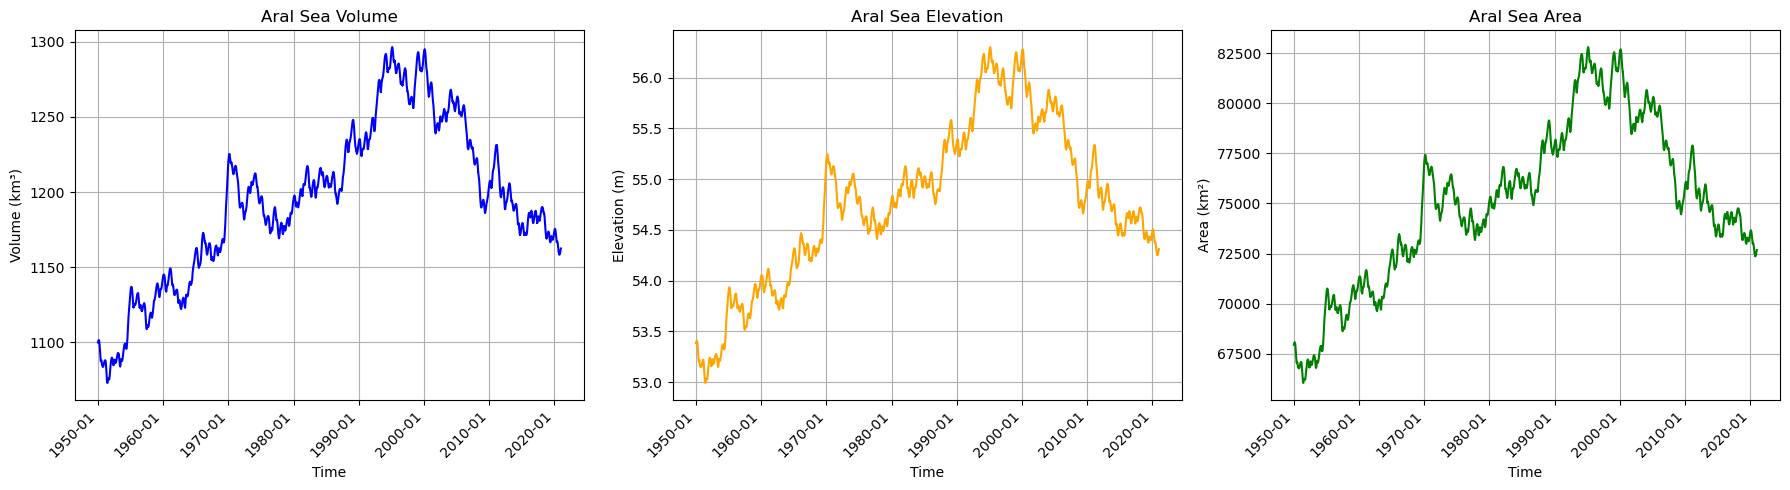

In [10]:
aral.plot_aral_results(df_aral)

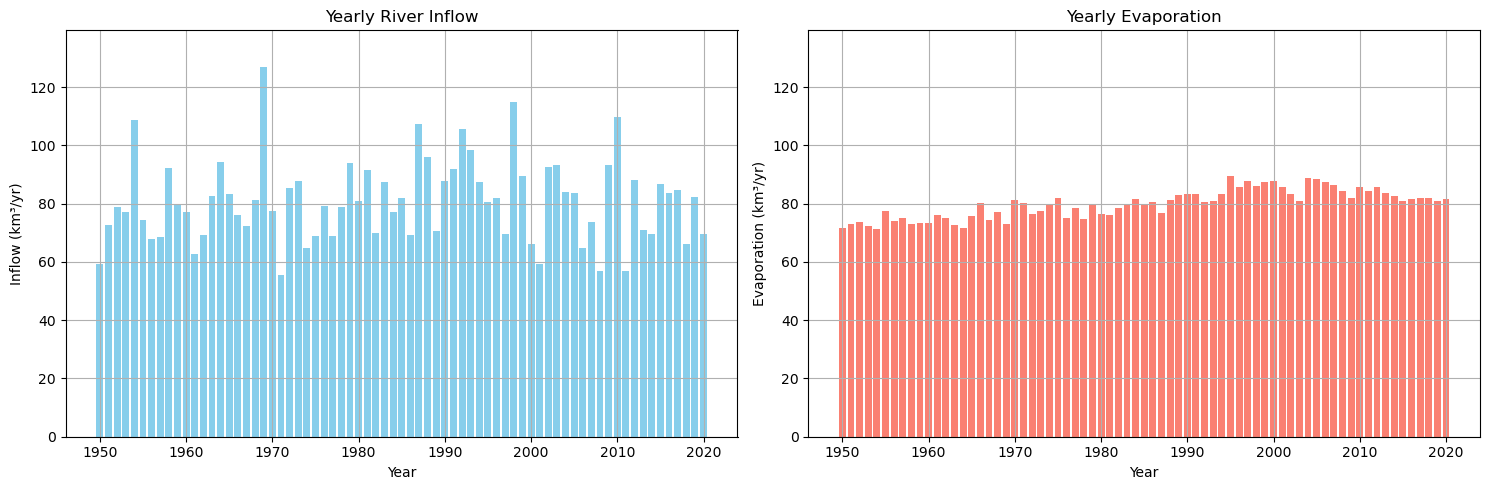

In [11]:
aral.plot_aral_fluxes(df_aral)

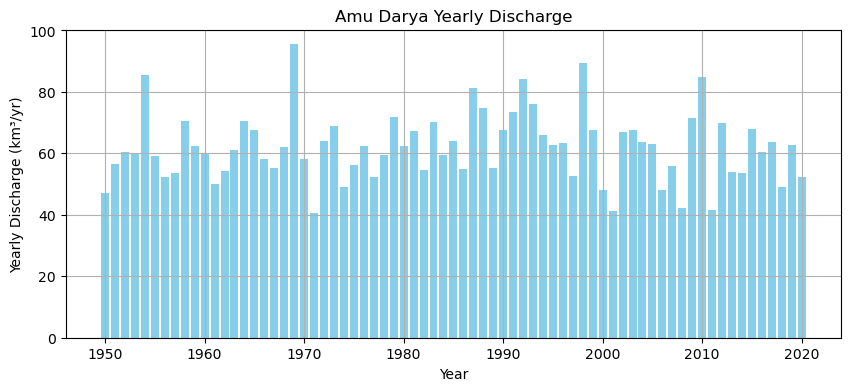

In [12]:
River_Amu_Darya.plot_yearly()


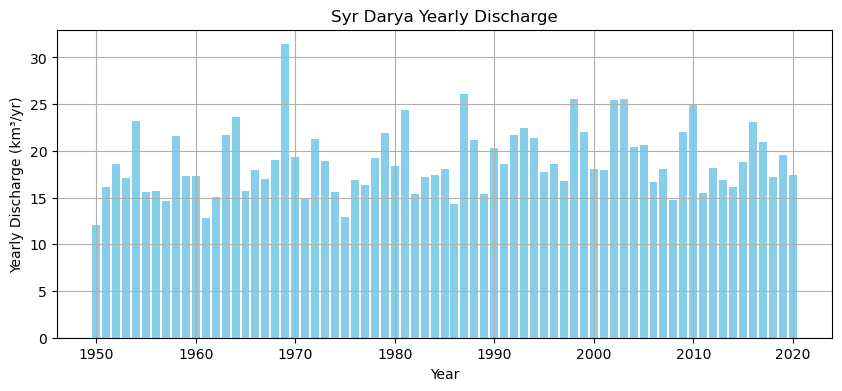

In [13]:
River_Syr_Darya.plot_yearly()

In [14]:
lake = aral.LakeGeometry(ahv_file)  # correct instantiation

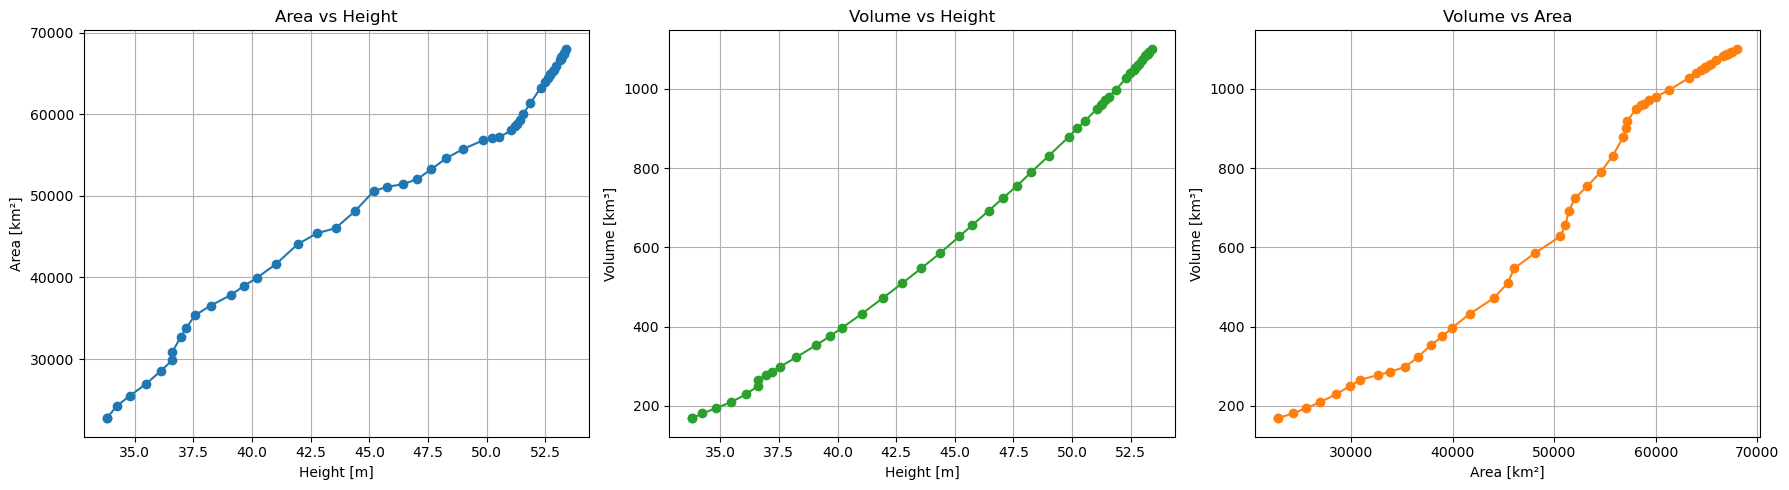

In [15]:
# 3️⃣ Plot the AHV curves
fig, axes = lake.plot_ahv_curve()  # <--- just call this on the instance
plt.show()

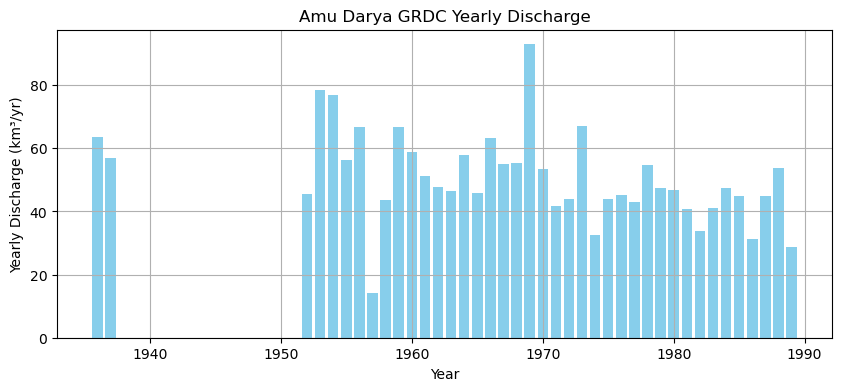

In [16]:
River_Amu_Darya_grdc.plot_yearly()

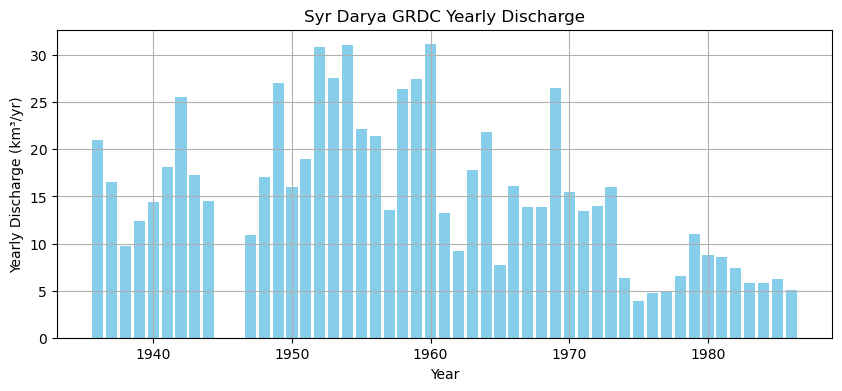

In [17]:
River_Syr_Darya_grdc.plot_yearly()

In [18]:
rivers_dict = {
    'Syr Darya GRDC': River_Syr_Darya_grdc,
    'Amu Darya GRDC': River_Amu_Darya_grdc,
    'Syr Darya Model': River_Syr_Darya,
    'Amu Darya Model': River_Amu_Darya
}

In [19]:
multi_river = aral.MultiRiver(rivers_dict)

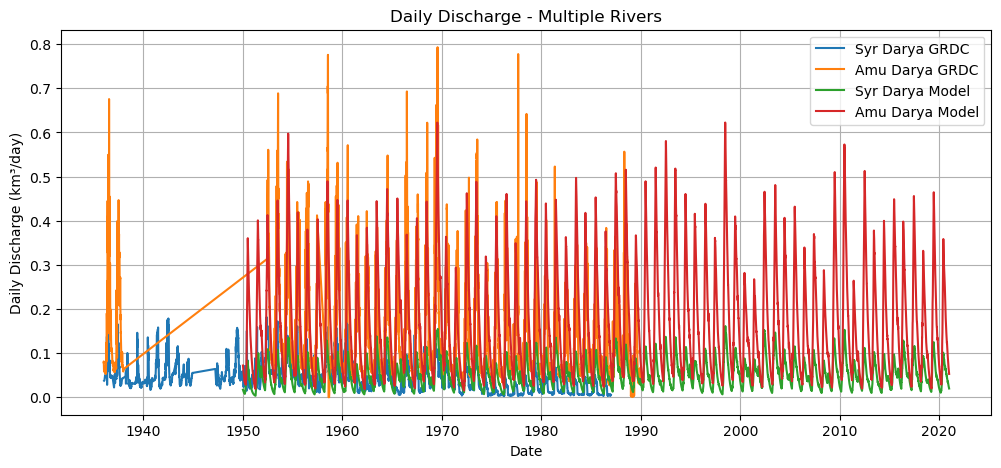

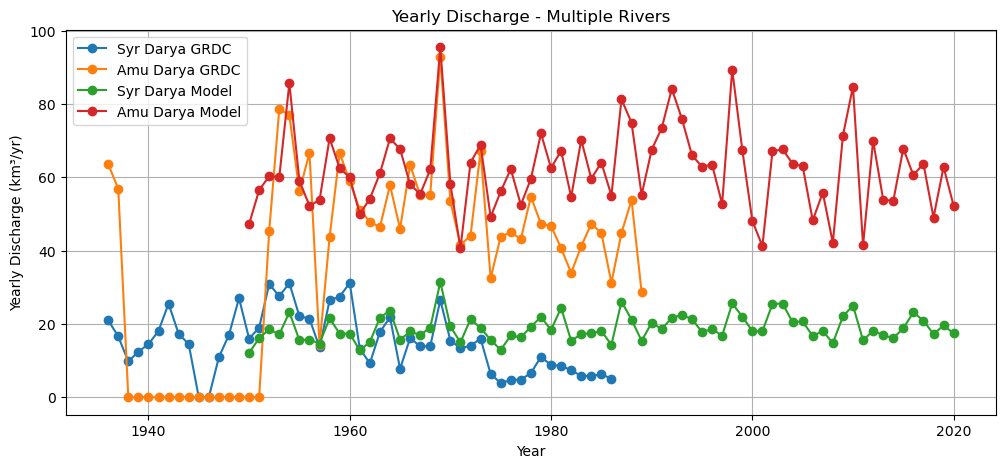

In [20]:
multi_river.plot_daily()
multi_river.plot_yearly()